In [1]:
# Initialize Otter
import otter
import stats

grader = otter.Notebook("sciPyPart1.ipynb")

## Lecture Section

In this lecture, we will cover the `scipy` library. Specifically, the `scipy.stats` module.
We will cover:
* Distributions (pdf, cdf), simulations (normal, binomial, etc.), and visualizations (plotting).
* Hypothesis testing
    * One-sample t-test
    * Two-sample t-test
    * Chi-square test of independence

### Simulations

Similar to `numpy`, we can simulate distributions with `scipy`, too. The underlying foundation of `SciPy` *is* `numpy`!

The code below simulates normal, uniform, and poisson distributions. It also shows some summary statistics of these distributions.

In [2]:
import scipy.stats as stats
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

normal_samples = stats.norm.rvs(loc=0, scale=1, size=1000)  # Normal Distribution
uniform_samples = stats.uniform.rvs(loc=0, scale=10, size=1000)  # Uniform distribution
poisson_samples = stats.poisson.rvs(mu=3, size=1000)  # Poisson distribution


print("Normal Distribution:")
print("Mean: ", np.mean(normal_samples))
print("Std Dev: ", np.std(normal_samples))

print("\nUniform Distribution:")
print("Mean: ", np.mean(uniform_samples))
print(f"Range: ", np.min(uniform_samples), " - ", np.max(uniform_samples))

print("\nPoisson Distribution:")
print("Mean: ", np.mean(poisson_samples))
print(f"Variance: ", np.var(poisson_samples))

Normal Distribution:
Mean:  -0.005126758831675812
Std Dev:  0.9319124441637053

Uniform Distribution:
Mean:  4.919876759166602
Range:  0.0008943759351454084  -  9.99905487891775

Poisson Distribution:
Mean:  3.006
Variance:  2.905964


Now, using matplotlib, we can plot each of these distributions. Make sure you understand the code below before moving on. Try removing setting the `kde` parameter to  `False` and see what happens!

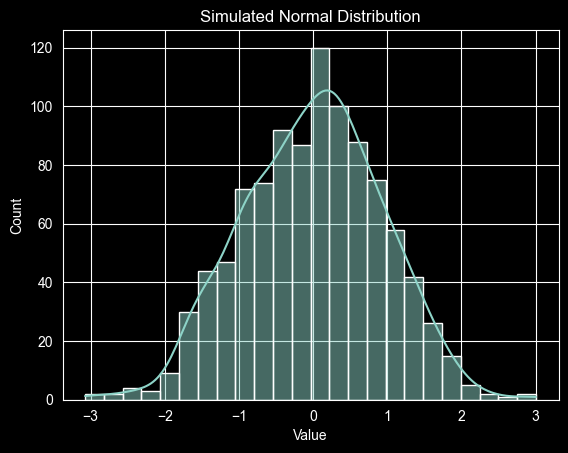

In [3]:
sns.histplot(normal_samples, kde=True)
plt.title("Simulated Normal Distribution")
plt.xlabel("Value")
plt.show()

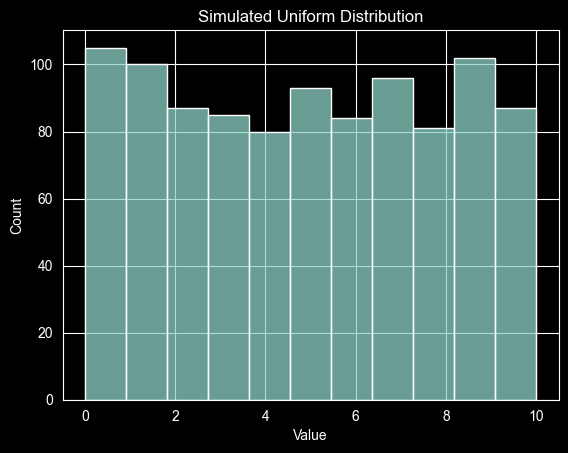

In [4]:
sns.histplot(uniform_samples, kde=False)
plt.title("Simulated Uniform Distribution")
plt.xlabel("Value")
plt.show()

We have to do a little extra work for the Poisson distribution, because Seaborn is trying to create bins for continuous data when we want one bar per integer value. We can directly tell it how many bins we want. Remember this when graphing discrete distributions!

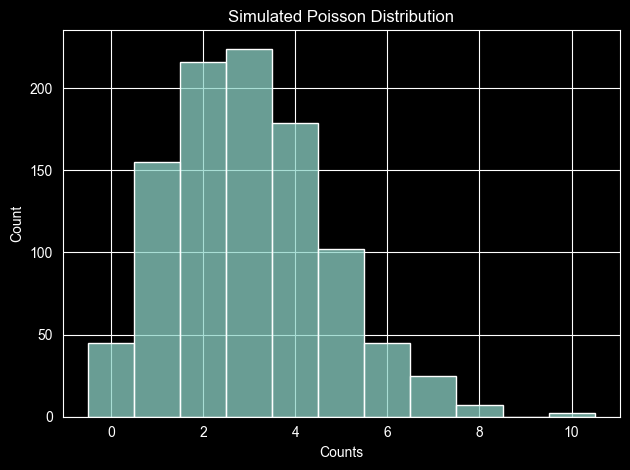

In [5]:
# Simulate Poisson Distribution
min_val, max_val = poisson_samples.min(), poisson_samples.max()
bins = np.arange(min_val - 0.5, max_val + 1.5, 1)  # bin edges centered on integers

sns.histplot(poisson_samples, bins=bins, kde=False)
plt.title("Simulated Poisson Distribution")
plt.xlabel("Counts")
plt.tight_layout()
plt.show()

### Working With Real Data

The section above was mostly review... let's try and use some real data. We will use the 1tips` dataset from `seaborn`.

https://www.kaggle.com/datasets/ranjeetjain3/seaborn-tips-dataset

In [6]:
tips = sns.load_dataset("tips")
print(tips.head(24))

    total_bill   tip     sex smoker  day    time  size
0        16.99  1.01  Female     No  Sun  Dinner     2
1        10.34  1.66    Male     No  Sun  Dinner     3
2        21.01  3.50    Male     No  Sun  Dinner     3
3        23.68  3.31    Male     No  Sun  Dinner     2
4        24.59  3.61  Female     No  Sun  Dinner     4
5        25.29  4.71    Male     No  Sun  Dinner     4
6         8.77  2.00    Male     No  Sun  Dinner     2
7        26.88  3.12    Male     No  Sun  Dinner     4
8        15.04  1.96    Male     No  Sun  Dinner     2
9        14.78  3.23    Male     No  Sun  Dinner     2
10       10.27  1.71    Male     No  Sun  Dinner     2
11       35.26  5.00  Female     No  Sun  Dinner     4
12       15.42  1.57    Male     No  Sun  Dinner     2
13       18.43  3.00    Male     No  Sun  Dinner     4
14       14.83  3.02  Female     No  Sun  Dinner     2
15       21.58  3.92    Male     No  Sun  Dinner     2
16       10.33  1.67  Female     No  Sun  Dinner     3
17       1

Let's say we want to estimate the probability of getting a tip over $5 a certain number of times. We can use what we've learned so far to do that!

Explaining the code below (by line number):
1. Creates a series of 0's and 1's. Each index corresponds to the same index in our dataset. If there is a 1, that means the tip at that particular index in our dataset is greater than 5. For example, the first tip greater than 5 in our dataset is at index 23, so index 23 is a 1 in our Series object.
2. Creates array of all our indexes so that we can plot in the future.
3. Adds the number of 1s we have in our Series object, effectively getting the number of tips greater than 5 from our dataset.
4. The total number of tips in our dataset. Don't let the variable name we are measuring fool you - it includes the 0s, too!


In [7]:
high_tip = (tips["tip"] > 5).astype(int)
x = np.arange(0, len(high_tip) + 1)
successes = high_tip.sum()
trials = len(high_tip)
high_tip

0      0
1      0
2      0
3      0
4      0
      ..
239    1
240    0
241    0
242    0
243    0
Name: tip, Length: 244, dtype: int64

In [8]:
trials

244

In [9]:
successes

np.int64(18)

Now we can get our probability distribution. Since we are working with successes/trials - this problem is clearly binomial. We use `stats.binom.pmf` to get our distribution. We set `n` to the number of trials, and `p` to our observed probability of success.

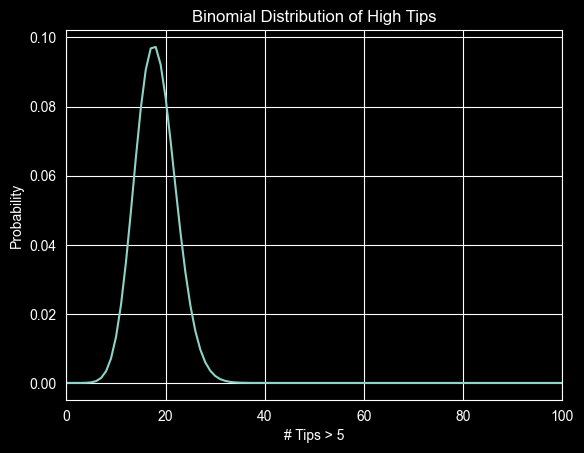

In [10]:
pmf = stats.binom.pmf(x, n=trials, p=successes/trials)
plt.plot(x, pmf)
plt.title("Binomial Distribution of High Tips")
plt.xlabel("# Tips > 5")
plt.ylabel("Probability")
plt.xlim(0, 100) # limits our x-axis
plt.show()

We have the highest probability of getting 20 tips greater than 5 dollars! Of course... that's if you're the sole server in the entire restaurant and your quality of service remains unchanged, though :)

FOr fun, we can also obtain the cdf, or cumulative distribution. It works as expected!

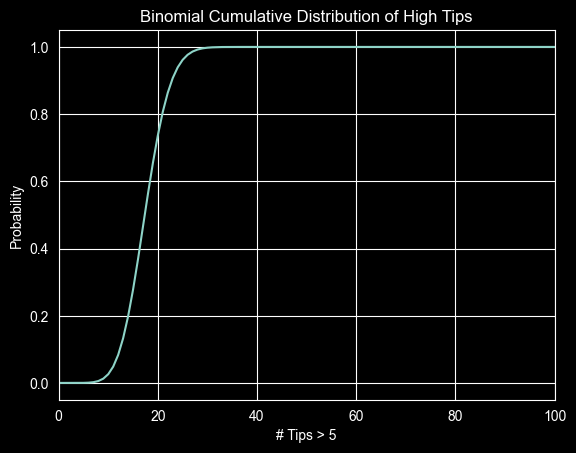

In [11]:
cdf = stats.binom.cdf(x, n=trials, p=successes/trials)
plt.plot(x, cdf)
plt.title("Binomial Cumulative Distribution of High Tips")
plt.xlabel("# Tips > 5")
plt.ylabel("Probability")
plt.xlim(0, 100) # limits our x-axis
plt.show()

Let's try one more problem!

This time, we want to model the distribution of the total bill. This follows a normal distribution, so we will use `stats.norm`. Like all normal distribution, we only need the mean and the standard deviation to create a model. Once we have those, we can call our `cdf`, `pdf`, and `ppf` (for discrete: `pmf`, too).
* `pmf` : probability mass function (discrete) - probability that a random variable takes on a particular value
* `pdf` : probability density function (continuous) - probability that a random variable falls between two numbers
* `cdf` : cumulative distribution function - probability that a random variable is less than or equal to a specific point (area under the `pdf` up to a certain point - integral of `pdf`)
* `ppf` : percentage point function/inverse cdf - provides the x values that a given percentage of observations fall below

In [12]:
mean_bill = tips["total_bill"].mean()
std_bill = tips["total_bill"].std()
print("P(X < 20):", stats.norm.cdf(20, loc=mean_bill, scale=std_bill)) # probability of total bill being less than $20
print("x such that P(X < x) = 0.95:", stats.norm.ppf(0.95, loc=mean_bill, scale=std_bill)) # observation x = $34.429... and all prior make up 95% of the distribution

P(X < 20): 0.50959159276498
x such that P(X < x) = 0.95: 34.42910721551326


We can plot the distribution, too!

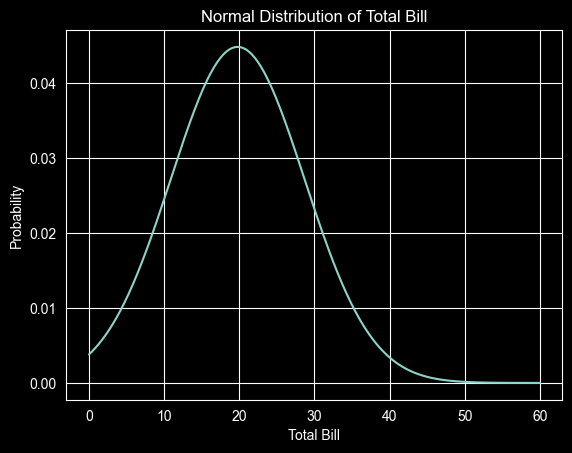

In [13]:
x = np.linspace(0, 60, 300)
plt.plot(x, stats.norm.pdf(x, loc=mean_bill, scale=std_bill))
plt.title("Normal Distribution of Total Bill")
plt.xlabel("Total Bill")
plt.ylabel("Probability")
plt.show()

And the cdf...

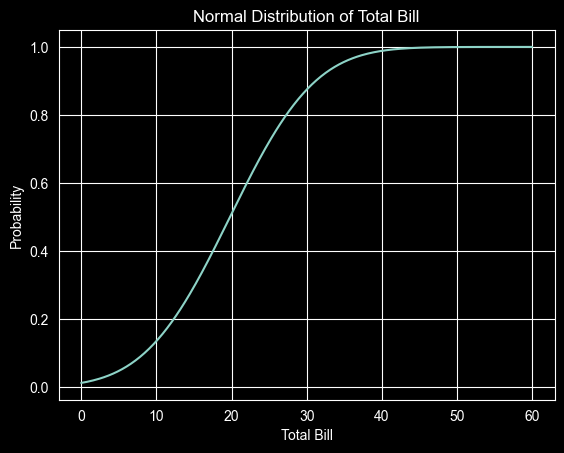

In [14]:
x = np.linspace(0, 60, 300)
plt.plot(x, stats.norm.cdf(x, loc=mean_bill, scale=std_bill))
plt.title("Normal Distribution of Total Bill")
plt.xlabel("Total Bill")
plt.ylabel("Probability")
plt.show()

### Hypothesis Testing

It is easy to do hypothesis testing in Python, too.

For example, maybe we hypothesize that the average total bill is around $20 dollars. To test this, we use `stats.ttest_1samp()`, or a 1-sample t-test. We give the column of data that we are interested in as the first argument, and we set `popmean` equal to our hypothesized value.

In [15]:
t_stat, p_val = stats.ttest_1samp(tips["total_bill"], popmean=20)
print("One-sample t-test p-value:", p_val)

print("\n\nActual mean: ", np.mean(tips["total_bill"]))

One-sample t-test p-value: 0.7075471935626721


Actual mean:  19.78594262295082


We don't have strong evidence to reject our null hypothesis, so we cannot say that the population's total bill is much different from $20.


We can also do two-sample t-tests. Let's compare the total_bill column for lunch and dinner groups. We want to know if the mean total bill for each group is equal. For this, we use `stats.ttest_ind()`. We give the columns of data we are comparing as the first two arguments, then we set `equal_var` to `True` (default) or `False`. A good rule of thumb: if the ratio of the large sample variance to the smaller is less than 4, we can generally assume the population variances are the same (or similar enough).

In [16]:
lunch = tips[tips["time"] == "Lunch"]["total_bill"]
dinner = tips[tips["time"] == "Dinner"]["total_bill"]
print(np.var(dinner)/np.var(lunch))
t_stat, p_val = stats.ttest_ind(lunch, dinner, equal_var=True)
print("Two-sample t-test (Lunch vs Dinner) p-value:", p_val)

1.4174205721634148
Two-sample t-test (Lunch vs Dinner) p-value: 0.004104621407595672


Our p-value is very small... it is likely that in the population, the average total bill of lunch-havers differs from dinner-goers!


We can also perform a chi-square test of independence. This test aims to determine if two categorical variables are related to one-another. WHen working with real data, it's often easier to create the contingency table for the `stats/chi2_contingency()` function. This function returns a lot of information, including the p-value, the degrees of freedom, and the expected frequencies.

In [17]:
contingency_table = pd.crosstab(tips["day"], tips["smoker"])
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
print("Chi-square test (Day vs Smoker) p-value:", p)
print('Expected: ', expected)

Chi-square test (Day vs Smoker) p-value: 1.0567572499836523e-05
Expected:  [[23.63114754 38.36885246]
 [ 7.24180328 11.75819672]
 [33.15983607 53.84016393]
 [28.96721311 47.03278689]]


If we have data that is already separated, the function will create the contingency table on its own:

In [18]:
data = [
    [7, 9, 8, 12, 5],  # Male: average work hours per day
    [8, 9, 10, 9, 6]   # Female: average work hours per day
]

chi2_stat, p_value, dof, expected = stats.chi2_contingency(data)

print("Chi-Square Statistic:", chi2_stat)
print("P-value:", p_value)
print('Expected: ', expected)

Chi-Square Statistic: 0.7964368255309028
P-value: 0.9389251186037576
Expected:  [[ 7.40963855  8.89156627  8.89156627 10.37349398  5.43373494]
 [ 7.59036145  9.10843373  9.10843373 10.62650602  5.56626506]]


Finally, scipy lets us easily do permutation tests. Permutation tests involve shuffling data-points between or within groups to create 'new' resampled datasets. The goal is to see how much the test statistic (in the case below: difference in means) varies across the 'new' datasets. Then, we want to know how often a test static like the one we observed in our real data occurs.

For more information on this process, check out this page:
https://jillxoreilly.github.io/StatsCourseBook/permutation_intro.html

In [19]:
smokers = tips[tips["smoker"] == "Yes"]["tip"]
non_smokers = tips[tips["smoker"] == "No"]["tip"]
def statistic(x, y):
    return np.mean(x) - np.mean(y)
perm_p = stats.permutation_test((smokers.values, non_smokers.values), statistic, n_resamples=10000, alternative='two-sided')
print("Permutation test (Smokers vs Non-Smokers tip) p-value:", perm_p.pvalue)

Permutation test (Smokers vs Non-Smokers tip) p-value: 0.9055094490550945


## Assignment Section

**Question 1.** We want to estimate the probability of our total bill being less than 8 dollars a certain number of times. Use the 'high_tip' example above to create the pmf graph.

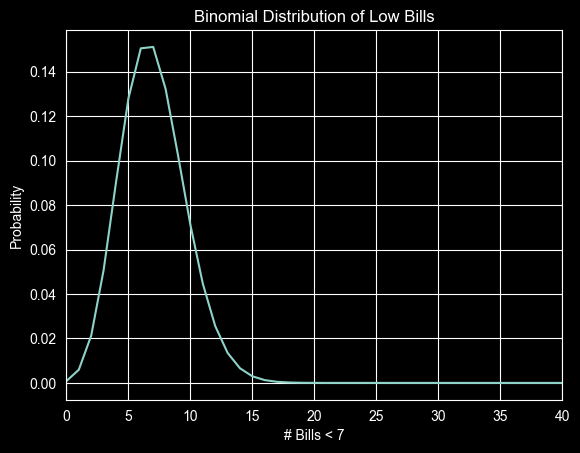

In [66]:
# Creating a new boolean variable to identify the samples that have a total bill of less than 8
low_bill = (tips["total_bill"] < 8).astype(int)
# Creating a range of all the possible success counts from 0 up to the total number of trials
x = np.arange(0, len(low_bill) + 1)
# Counting the total number of bills that were under 8
successes = low_bill.sum()
# Counting the overall number of bills (observations)
trials = len(low_bill)

# Generating the PMF based on the number of successes
pmf = stats.binom.pmf(x, n=trials, p=successes/trials)
# Creating the PMF plot as well as creating the title and axis labels
plt.plot(x, pmf)
plt.title("Binomial Distribution of Low Bills")
plt.xlabel("# Bills < 7")
plt.ylabel("Probability")
plt.xlim(0, 40) # limits our x-axis
plt.show()


In [67]:
grader.check("q1")

q1 results: All test cases passed!

**Question 2.** We hypothesize that the average tip is around $3 dollars. Test this with a one-sample t-test.

In [68]:
# Generating a one-sample test and printing the result
t_stat, p_val = stats.ttest_1samp(tips["tip"], popmean=3)
print("One-sample t-test for tip vs $3:", p_val)


One-sample t-test for tip vs $3: 0.9845119176410543


In [69]:
grader.check("q2")

q2 results: All test cases passed!

**Question 3.** Run a permutation test between lunch total_bill and dinner total_bill. Use 10,000 for n_resamples.

In [70]:
# Creating variables that identify the 'lunch' and 'dinner' categories in the 'total_bill' column
lunch = tips[tips["time"] == "Lunch"]["total_bill"]
dinner = tips[tips["time"] == "Dinner"]["total_bill"]
# Calculating the difference between the averages of 'lunch' and 'dinner'
def statistic(x, y):
    return np.mean(x) - np.mean(y)
# Running the permutation test and printing the result
perm_p = stats.permutation_test((lunch.values, dinner.values), statistic, n_resamples=10000, alternative='two-sided')
print("Permutation test (Lunch vs Dinner Total Bill) p-value:", perm_p.pvalue)


Permutation test (Lunch vs Dinner Total Bill) p-value: 0.0015998400159984002


In [71]:
grader.check("q3")

q3 results: All test cases passed!

**Question 4.** We want to model the distribution of the 'tips' by assuming it folllows a normal distribution. Then, find the probability that a randomly selected tip is greater than or equal to $5.

In [72]:
import seaborn as sns
from scipy import stats

# Calculating the mean and standard deviation of the 'tip' variable
mean_tip = tips["tip"].mean()
std_tip = tips["tip"].std()
# Calculating the probability based on the mean and std and printing the result
ans = stats.norm.sf(5, loc=mean_tip, scale=std_tip)
print("P(X >= 5):", ans) # tip being greater than 5


P(X >= 5): 0.07398927292643863


In [73]:
grader.check("q4")

q4 results: All test cases passed!

---

To double-check your work, the cell below will rerun all of the autograder tests.

In [74]:
grader.check_all()

q1 results: All test cases passed!

q2 results: All test cases passed!

q3 results: All test cases passed!

q4 results: All test cases passed!